In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Cleaned_Sales_Dataset.csv")

In [3]:
#Convert Order_Date
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [4]:
#Create Invoice Month
df['Order_Month'] = df['Order_Date'].dt.to_period('M')

In [5]:
 #First Purchase Month
df['Cohort_Month'] = df.groupby('Customer_ID')['Order_Month'].transform('min')

In [6]:
#Calculate Cohort Index
df['Cohort_Index'] = (
    (df['Order_Month'].dt.year - df['Cohort_Month'].dt.year) * 12
    +
    (df['Order_Month'].dt.month - df['Cohort_Month'].dt.month)
    + 1
)

In [7]:
#Create Cohort Table
cohort_data = df.groupby(
    ['Cohort_Month','Cohort_Index']
)['Customer_ID'].nunique().reset_index()

In [8]:
# Pivot Table
cohort_table = cohort_data.pivot(
    index='Cohort_Month',
    columns='Cohort_Index',
    values='Customer_ID'
)

In [9]:
#Retention Matrix
cohort_size = cohort_table.iloc[:,0]

retention = cohort_table.divide(cohort_size, axis=0)

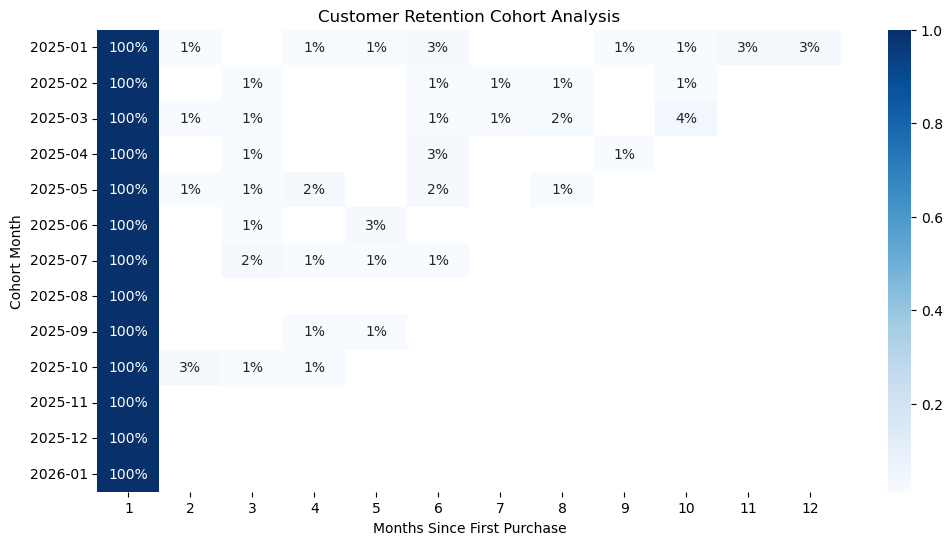

In [10]:
#Plot Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

In [11]:
#Customer Lifetime Value
customer_revenue = df.groupby('Customer_ID')['Total_Sales'].sum()

clv = customer_revenue.mean()

print("Average Customer Lifetime Value:", round(clv,2))

Average Customer Lifetime Value: 147201.1


In [12]:
#Top 10 Customers
top_customers = df.groupby('Customer_ID')['Total_Sales'] \
                  .sum() \
                  .sort_values(ascending=False) \
                  .head(10)

print(top_customers)

Customer_ID
CUST9510    867333.24
CUST6845    769479.75
CUST6532    610981.74
CUST6082    548416.39
CUST3689    542484.08
CUST3730    538633.97
CUST4706    528036.44
CUST9693    511421.86
CUST7374    511309.40
CUST2062    493677.50
Name: Total_Sales, dtype: float64
